In [1]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt

In [2]:
# pulizia per sicurezza

#os.system("rm *.h5")
os.system("rm summary.h5")
os.system("rm *.xml")
os.system("rm *.out")
os.system("rm *.png")

rm: cannot remove 'summary.h5': No such file or directory
rm: cannot remove '*.xml': No such file or directory
rm: cannot remove '*.out': No such file or directory
rm: cannot remove '*.png': No such file or directory


256

In [3]:
# VARIABILI DA PAPERMILL (verranno sovrascritte)
pressione_atm = 1.0
moltiplicatore = 1.0
perc_water = 0.15
arricch_max = 13.469  # in percentuale
arricch_min = 1.0     # in percentuale
t_water = 350.0
t_fuel = 600.0
run_id = "default"

VARIABILI IMPORTANTI

In [ ]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters("../../parametri.txt")

# --- Parametri Geometrici e Logici ---
R_CORE    = p['R_CORE']*moltiplicatore
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']
R_PIPE    = p['R_PIPE']

# --- Parametri Target e Sorgente ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']
S         = p['S']
bin_ris   = p['bin_ris']
batches   = p['batches_fix']
particles = p['particles_fix']

# --- Parametri Pin/Lattice Base ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']

enrich_target = p['enrich_target']

# ==========================================
# SOVRASCRITTURA CON PARAMETRI DI PAPERMILL
# ==========================================
Pressione_funzionamento = pressione_atm * 101325  # atm in Pa
PITCH     = p['PITCH'] * moltiplicatore
mix       = perc_water
T_water   = t_water
T_resto   = t_fuel

# I valori dal txt sono in percentuale, convertiamoli in frazione
enrich_max = arricch_max / 100.0
enrich_min = arricch_min / 100.0


In [6]:
from CoolProp.CoolProp import PropsSI

def densita_mix_dinamica(T_K, P_Pa= Pressione_funzionamento, frac_mass_H2O=mix):
    # Calcolo in kg/m^3 e conversione in g/cm^3
    rho_H2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'Water') / 1000     # D sta per densità
    rho_D2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'HeavyWater') / 1000
    
    # Calcolo miscela assumendo volumi ideali additivi
    rho_mix = 1 / (frac_mass_H2O / rho_H2O + (1 - frac_mass_H2O) / rho_D2O) # Formula di additività dei volumi specifici
    return rho_mix

print(f"Densità del mix a {T_water} K e {Pressione_funzionamento/1e6} MPa: {densita_mix_dinamica(T_water, Pressione_funzionamento, mix):.4f} g/cm^3")

Densità del mix a 350.0 K e 0.101325 MPa: 1.0629 g/cm^3


MATERIALI

In [7]:
# materiale di rivestimento
cladding = openmc.Material(name='cladding')
cladding.temperature = T_resto
cladding.add_element('Zr', 1.0) 
cladding.set_density('g/cm3', 6.49)

# materiale di moderatore
water = openmc.Material(name='water')
water.temperature = T_water
water.add_nuclide('H1', mix)
water.add_nuclide('H2', 1-mix)
water.add_element('O', 1.0)
water.set_density('g/cm3', densita_mix_dinamica(T_water)) # Usa la densità corretta
water.add_s_alpha_beta('c_D_in_D2O') 
water.add_s_alpha_beta('c_H_in_H2O') 

# aggiungo un riflettore 
reflector = openmc.Material(name='reflector')
reflector.temperature = T_resto
reflector.add_element('C', 1.0)
reflector.set_density('g/cm3', 1.75) 

# voglio una sorgente puntiforme di neutroni in un punto specifico
marker_mat = openmc.Material(name='marker')
marker_mat.temperature = T_resto
marker_mat.set_density('g/cm3', 1e-10) 
marker_mat.add_nuclide('He4', 1.0) 

void_air = openmc.Material(name='void_air')
void_air.temperature = T_resto
void_air.set_density('g/cm3', 1e-10) 
void_air.add_nuclide('N14', 1)

mat_target = openmc.Material(name='mat_target')
mat_target.temperature = T_resto
mat_target.add_nuclide('U235', enrich_target)
mat_target.add_nuclide('U238', 1.0 - enrich_target)
mat_target.add_nuclide('O16', 2.0)
mat_target.set_density('g/cm3', 10.96)

GEOMETRIA

In [ ]:
# --- 0. PIANI Z (ASSOLUTI) ---
z_bot_ref = openmc.ZPlane(z0=-REF_BOT, boundary_type='vacuum')
z_bot_core = openmc.ZPlane(z0=0.0)
z_top_core = openmc.ZPlane(z0=H_CORE)
z_top_world = openmc.ZPlane(z0=H_CORE + 5.0, boundary_type='vacuum')

# Piani Z Target
z_mid = H_CORE - P_TARGET
z_tgt_bot = openmc.ZPlane(z0=z_mid - (H_TARGET / 2.0))
z_tgt_top = openmc.ZPlane(z0=z_mid + (H_TARGET / 2.0))

# Superficie Sorgente
sphere_src = openmc.Sphere(x0=0, y0=0, z0=H_CORE + 2, r=0.5)

# --- 1. CALCOLO DIMENSIONI TAGLIO CENTRALE ---
# Calcoliamo quanto deve essere grande il buco esagonale centrale
# Rimuoviamo gli anelli che cadono dentro R_PIPE
n_rings_removed = int(np.ceil(R_PIPE / PITCH))
# Il lato del prisma che useremo per "bucare" il lattice:
EDGE_PIPE_LARGE = (n_rings_removed - 0.5) * PITCH
if EDGE_PIPE_LARGE == 0: EDGE_PIPE_LARGE = PITCH # Sicurezza minima

# --- 2. FORME GEOMETRICHE BASE ---

EDGE_FUEL = R_FUEL
EDGE_CLAD = R_FUEL + CLAD_THICK

# A. Prismi PIN
hex_fuel_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_FUEL, orientation='x')
hex_clad_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_CLAD, orientation='x')

# B. Prisma "TAGLIO" CENTRALE (Il buco grande nel reticolo)
hex_pipe_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_PIPE_LARGE, orientation='x')

# C. Cilindro Target (Unico centrale)
cyl_target = openmc.ZCylinder(r=R_TARGET)

# --- 3. UNIVERSI ---
fuel_mats = []
fuel_universes = []

num_rings = int(np.ceil(R_CORE / PITCH)) + 1

for i in range(num_rings):
    # Interpolazione lineare arricchimento
    if num_rings > 1:
        e_i = enrich_max - (enrich_max - enrich_min) * (i / (num_rings - 1))
    else:
        e_i = enrich_max

    # Materiale
    f = openmc.Material(name=f'fuel_ring_{i}')
    f.temperature = T_resto
    f.add_nuclide('U235', e_i)
    f.add_nuclide('U238', 1.0 - e_i)
    f.add_nuclide('O16', 2.0)
    f.set_density('g/cm3', 10.96)
    fuel_mats.append(f)
    
    # Cella e Universo
    c_f = openmc.Cell(fill=f, region=hex_fuel_prism)
    c_c = openmc.Cell(fill=cladding, region=hex_clad_prism & ~hex_fuel_prism)
    c_w = openmc.Cell(fill=water, region=~hex_clad_prism)
    fuel_universes.append(openmc.Universe(cells=[c_f, c_c, c_w]))

# Esportazione xml iniziale
materials = openmc.Materials(fuel_mats + [cladding, water, reflector, marker_mat, void_air, mat_target])
#materials.cross_sections = "/home/bossi_ricky/openmc_data/mcnp_endfb71/cross_sections.xml"
materials.cross_sections = "/raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/cross_sections.xml"
    

materials.export_to_xml()


# C. Universo ACQUA ESTERNA (Riflettore/Gap)
c_water_full = openmc.Cell(fill=water)
u_water = openmc.Universe(cells=[c_water_full])


# --- 4. LATTICE (SOLO COMBUSTIBILE) ---
# Creiamo un lattice uniforme pieno SOLO di pin.
# Il buco centrale lo creiamo geometricamente nello step successivo, non qui.

hex_core_edge = num_rings * PITCH
hex_ref_edge = hex_core_edge + REF_SIDE

lattice_universes = []
for i in range(num_rings):
    if i == 0:
        lattice_universes.append([fuel_universes[i]])
    else:
        lattice_universes.append([fuel_universes[i]] * (6 * i))

lattice = openmc.HexLattice(name='core_hex_lattice')
lattice.center = (0.0, 0.0)
lattice.pitch = (PITCH,)
lattice.outer = u_water
lattice.universes = lattice_universes[::-1] # Inversione fondamentale: Esterno -> Interno
lattice.orientation = 'x'

# --- 5. ASSEMBLAGGIO FINALE (GEOMETRIA DIRETTA) ---

prism_core = openmc.model.get_hexagonal_prism(edge_length=hex_core_edge, orientation='x')
prism_reflector = openmc.model.get_hexagonal_prism(edge_length=hex_ref_edge, orientation='x', boundary_type='vacuum')

# A. Cella Core (Lattice CON BUCO)
# ---------------------------------------------------------
# Prendiamo il prisma grande del core, e sottraiamo (~) il prisma del canale centrale.
# In questo modo il lattice viene "tagliato" via dal centro.
region_core = prism_core & ~hex_pipe_prism & +z_bot_core & -z_top_core
c_main_core = openmc.Cell(fill=lattice, region=region_core)


# B. Canale Centrale (Target + Vuoto) - DEFINIZIONE DIRETTA
# ---------------------------------------------------------
# 1. Definiamo il volume TOTALE del canale esagonale (da 0 a H_CORE)
region_central_hex_total = hex_pipe_prism & +z_bot_core & -z_top_core

# 2. Definiamo la regione del TARGET SOLIDO (Cilindro limitato in Z)
# Nota: Intersechiamo con region_central_hex_total per sicurezza, ma basterebbe il cilindro.
region_target_solid = region_central_hex_total & -cyl_target & +z_tgt_bot & -z_tgt_top

# 3. Definiamo la regione del VUOTO (Tutto il canale MENO il target)
# Usiamo l'operatore ~ (NOT) sulla regione del target.
region_void_gap = region_central_hex_total & ~region_target_solid

# Creazione delle celle
c_target = openmc.Cell(fill=mat_target, region=region_target_solid)
c_void_gap = openmc.Cell(fill=void_air, region=region_void_gap) 

# C. Riflettori (Rimangono uguali)
region_ref_side = prism_reflector & ~prism_core & +z_bot_core & -z_top_core
c_ref_side = openmc.Cell(fill=reflector, region=region_ref_side)

region_ref_bot = prism_reflector & +z_bot_ref & -z_bot_core
c_ref_bot = openmc.Cell(fill=reflector, region=region_ref_bot)

# D. Top World & Source (Rimangono uguali)
c_source_marker = openmc.Cell(fill=marker_mat, region=-sphere_src)
region_top = prism_reflector & +z_top_core & -z_top_world & +sphere_src
c_top_void = openmc.Cell(fill=void_air, region=region_top)

all_cells = [c_main_core, c_target, c_void_gap, c_ref_side, c_ref_bot, c_source_marker, c_top_void]
geometry = openmc.Geometry(all_cells)
geometry.export_to_xml()
print("Geometria generata correttamente.")

def count_fuel_pins(num_rings, pitch, r_pipe, r_core):
    total_pins = 0
    # Ring 0 è il centro
    for i in range(num_rings):
        ring_radius = i * pitch
        # Se l'anello è fuori dalla pipe centrale e dentro il raggio del core
        if ring_radius >= r_pipe and ring_radius <= r_core:
            if i == 0:
                total_pins += 1
            else:
                total_pins += (6 * i)
    return total_pins

n_barre = count_fuel_pins(num_rings, PITCH, R_PIPE, R_CORE)
print(f"Numero di barre di combustibile effettive: {n_barre} \n\n")

Geometria generata correttamente.
Numero di barre di combustibile effettive: 390 




/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:130: FutureWarning: get_hexagonal_prism(...) has been renamed hexagonal_prism(...). Future versions of OpenMC will not accept get_hexagonal_prism.
  warn("get_hexagonal_prism(...) has been renamed hexagonal_prism(...). "
/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:121: FutureWarning: The hexagonal_prism(...) function has been replaced by the HexagonalPrism(...) class. Future versions of OpenMC will not accept hexagonal_prism.
  warn("The hexagonal_prism(...) function has been replaced by the "


PLOTTING

/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/plots.py:1307: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(



VISUALIZZAZIONE GEOMETRIA

1. VISTA DALL'ALTO (Piano XY nel Core)


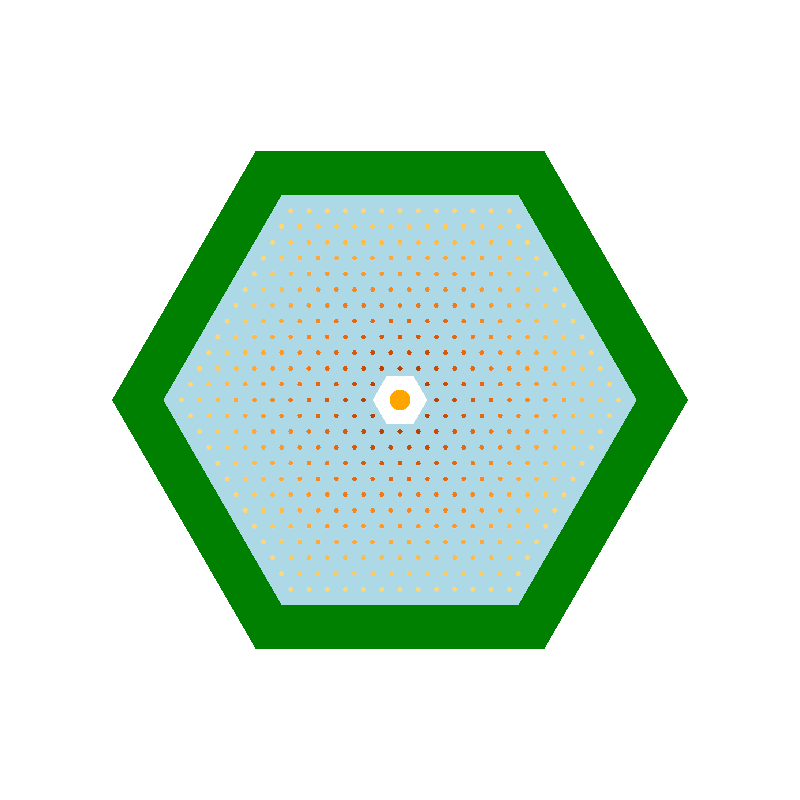

2. VISTA LATERALE (Piano XZ)


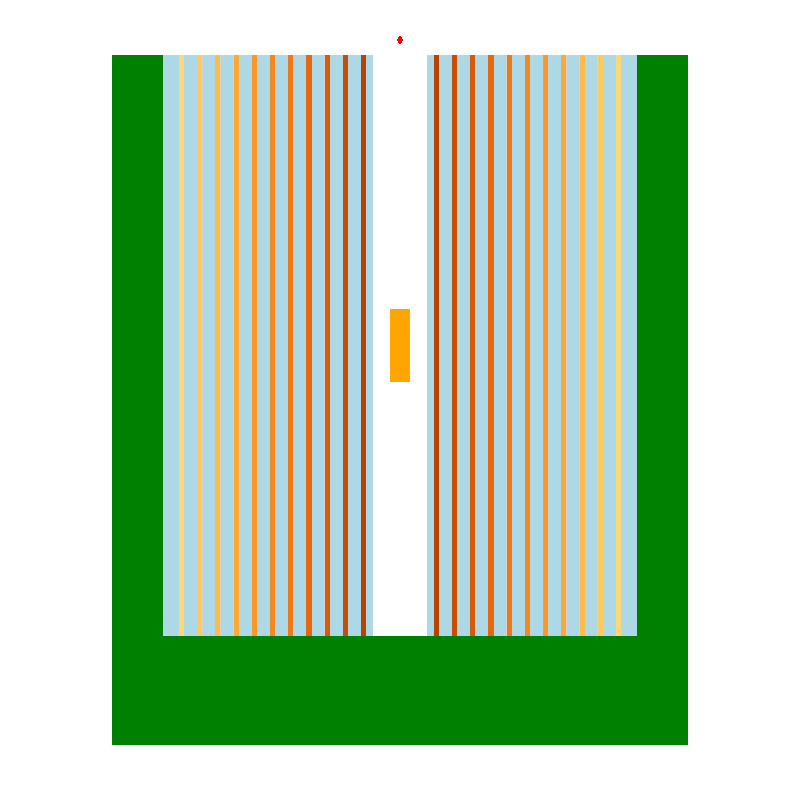

In [9]:
color_map = {
    cladding: 'lightgray',  # Cladding
    water: 'lightblue',     # Moderatore (acqua)
    reflector: 'green',     # Riflettore
    marker_mat: 'red' ,     # Marker sorgente
    void_air: 'white',      # Vuoto (aria)
    mat_target: 'orange'   # Target
}

cmap = plt.get_cmap('YlOrBr')

for i, f in enumerate(fuel_mats):
    if num_rings > 1:
        # Normalizziamo l'indice: 0 (centro, max arricchimento) -> 1 (esterno, min arricchimento)
        norm_val = i / (num_rings - 1)
    else:
        norm_val = 0.5
        
    rgba = cmap(0.9 - norm_val * 0.6)
    
    # OpenMC richiede tuple RGB con valori interi 0-255
    rgb_color = (int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))
    color_map[f] = rgb_color

# A. Vista dall'alto (Sezione nel mezzo del core)
p1 = openmc.Plot()
p1.basis = 'xy'
p1.origin = (0.0, 0.0, H_CORE / 2.0)
p1.width = (3 * (R_CORE + REF_SIDE + 2.0), 3 * (R_CORE + REF_SIDE + 2.0))
p1.pixels = (800, 800)
p1.color_by = 'material'
p1.colors = color_map
p1.filename = 'reactor_xy'

# B. Vista laterale (Sezione verticale XZ)
p2 = openmc.Plot()
p2.basis = 'xz'
p2.origin = (0.0, 0.0, (H_CORE - REF_BOT) / 2.0) 
p2.width = (3 * (R_CORE + REF_SIDE + 2.0), H_CORE + REF_BOT + 15.0)
p2.pixels = (800, 800)
p2.color_by = 'material'
p2.colors = color_map
p2.filename = 'reactor_xz'

# Esporto tutti i plot nel file XML
plots = openmc.Plots([p1, p2])
plots.export_to_xml()

# Eseguo il plotter: ho rimosso open_browser=False che causava l'errore
# OpenMC genererà i file .png basandosi sui nomi definiti (reactor_xy.png, ecc.)
openmc.plot_geometry() 

print("\n" + "="*30)
print("VISUALIZZAZIONE GEOMETRIA")
print("="*30 + "\n")

print("1. VISTA DALL'ALTO (Piano XY nel Core)")
display(Image('reactor_xy.png'))

print("2. VISTA LATERALE (Piano XZ)")
display(Image('reactor_xz.png'))

SETTINGS FIXED

In [ ]:
# Lettura dello spettro in energia
data = np.loadtxt("../../fixed/synchrotron_1_37_MeV.txt")
energy_midpoints, pdf_array = data[:,0], data[:,1]
energy_dist = openmc.stats.Tabular(energy_midpoints, pdf_array, interpolation='linear-linear')

# Definizione della sorgente
source = openmc.IndependentSource()
source.space = openmc.stats.Point((0, 0, H_CORE + 2.0))
source.angle = openmc.stats.Monodirectional((0, 0, -1))
source.energy = energy_dist
source.particle = 'photon'

# Impostazioni di simulazione
settings = openmc.Settings()

# Gestione particelle perse (alza il limite se la geometria è complessa ma corretta)
settings.max_lost_particles = 50

settings.batches = batches
settings.particles = particles
settings.run_mode = 'fixed source'

settings.cutoff = {'weight': 1.0e-5, 'energy_photon': 1.0e6} # cutoff a 1 MeV per i fotoni, così non simulo fotoni che non mi interessano
settings.temperature = {'method': 'interpolation'}

settings.max_collisions = 10000

settings.source = source

settings.photon_transport = True
settings.photonuclear_physics = True
settings.create_fission_neutrons = True

settings.export_to_xml()

# METTI TRACKING DEI NEUTRONI

TALLIES

In [12]:
tallies = openmc.Tallies()
#
## --- A. MESH E TALLY ASSIALE ---
#mesh_z = openmc.RegularMesh()
#mesh_z.dimension = [1, 1, bin_ris]
#mesh_z.lower_left = [-R_CORE, -R_CORE, 0.0]
#mesh_z.upper_right = [R_CORE, R_CORE, H_CORE]
#
## --- B. MESH E TALLY 2D (MAPPA FISSIONI) ---
#bound_xy = R_CORE + REF_SIDE 
#mesh_2d = openmc.RegularMesh()
#mesh_2d.dimension = [bin_ris, bin_ris, 1]
#mesh_2d.lower_left = [-bound_xy, -bound_xy, H_CORE/2.0 - 0.25] # mesh su una fetta alta 0.5 cm al centro del core
#mesh_2d.upper_right = [bound_xy, bound_xy, H_CORE/2.0 + 0.25]
#
#mesh_2d_flux = openmc.RegularMesh()     # mesh per il flusso in mezzo reattore
#mesh_2d_flux.dimension = [bin_ris, bin_ris, 1]
#mesh_2d_flux.lower_left = [0 , -bound_xy, H_CORE/2.0 - 0.25]
#mesh_2d_flux.upper_right = [bound_xy, bound_xy, H_CORE/2.0 + 0.25]   
#
#filter_termico = openmc.EnergyFilter([0.0, 0.625])
#filter_veloce = openmc.EnergyFilter([0.625, 20.0e6])
#neutron_filter = openmc.ParticleFilter(['neutron'])
#photon_filter = openmc.ParticleFilter(['photon'])
#
## ---------------------------------------------------------------------------------------------------------------------
#
## --- Tally per i profili assiali di neutroni e fotoni ---
#tally_n = openmc.Tally(name='profilo_neutroni')
#tally_n.filters = [openmc.MeshFilter(mesh_z), neutron_filter]
#tally_n.scores = ['flux']
#tallies.append(tally_n)
#tally_p = openmc.Tally(name='profilo_fotoni')
#tally_p.filters = [openmc.MeshFilter(mesh_z), photon_filter]
#tally_p.scores = ['flux']
#tallies.append(tally_p)
#
## Tally mappa fission
#tally_map = openmc.Tally(name='mappa_fissioni')
#tally_map.filters = [openmc.MeshFilter(mesh_2d), neutron_filter]
#tally_map.scores = ['nu-fission', 'fission', 'absorption', 'flux']
#tallies.append(tally_map)
#
#tally_flusso_termico = openmc.Tally(name='flusso_termico')
#tally_flusso_termico.filters = [openmc.MeshFilter(mesh_2d_flux), filter_termico, neutron_filter]
#tally_flusso_termico.scores = ['flux']
#tallies.append(tally_flusso_termico)
#
#tally_flusso_veloce = openmc.Tally(name='flusso_veloce')
#tally_flusso_veloce.filters = [openmc.MeshFilter(mesh_2d_flux),  filter_veloce, neutron_filter]
#tally_flusso_veloce.scores = ['flux']
#tallies.append(tally_flusso_veloce)
#
## Tally spettro energetico totale (neutroni + fotoni)
#energies = np.logspace(-3, 7.6, 501)    #corrisponde a circa 40 Mev
#tally_spec = openmc.Tally(name='spettro_energetico')
#tally_spec.filters = [openmc.EnergyFilter(energies), openmc.ParticleFilter(['neutron', 'photon'])]
#tally_spec.scores = ['flux']
#tallies.append(tally_spec)

fission_tot = openmc.Tally(name='fission_tot')
fission_tot.scores = ['fission']
tallies.append(fission_tot)

tallies.export_to_xml()


In [ ]:
import os
import glob
import shutil

percorso_eseguibile = "/home/bossi_ricky/miniconda3/envs/openmc-env/bin/openmc"
openmc.run( output=True, geometry_debug=False)

# Rinomina l'ultimo statepoint generato
sp_files = glob.glob('statepoint.*.h5')

if sp_files:
    latest_sp = max(sp_files, key=os.path.getctime)
    new_sp_name = f"statepoint_{run_id}.h5"
    shutil.move(latest_sp, new_sp_name)
    print(f"File statepoint salvato con successo: {new_sp_name}")
else:
    # Questo solleva un errore se OpenMC non ha prodotto il file, bloccando run_pot.py
    raise FileNotFoundError("ERRORE CRITICO: OpenMC NON ha generato alcun file statepoint! Controlla i settings.")

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

KeyboardInterrupt: 